In [1]:
!pip install --upgrade pip
!pip install umap-learn hdbscan numba==0.60.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [3]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score

FILE = "Merge_Completo_vigencia_total.parquet"
COL_ID   = "AFILIADO_ID_EPS"
COL_FINI = "FECHA_INICIO"
COL_FFIN = "FECHA_FIN"

dfa = pd.read_parquet(FILE)

dfa['FECHA_INICIO'] = pd.to_datetime(dfa['FECHA_INICIO'], errors='coerce')
dfa['FECHA_FIN']     = pd.to_datetime(dfa['FECHA_FIN'], errors='coerce')

# Meses transcurridos

meses = (dfa['FECHA_FIN'].dt.year - dfa['FECHA_INICIO'].dt.year) * 12 + \
        (dfa['FECHA_FIN'].dt.month - dfa['FECHA_INICIO'].dt.month)

ajuste_mes = (dfa['FECHA_FIN'].dt.day < dfa['FECHA_INICIO'].dt.day).astype(int)

dfa['meses_transcurridos'] = meses - ajuste_mes

dfa['meses_transcurridos'] = dfa['meses_transcurridos'].clip(lower=0)

# Para Excluir FALLA_BIN==0 y meses<12

cond_excluir = (dfa['FALLA_BIN'] == 0) & (dfa['meses_transcurridos'] < 12)
df_filtrado = dfa.loc[~cond_excluir].copy()

In [4]:
def build_X_sparse(df_in, drop_cancel_cols=False):
    df = df_in.copy()

    cat_code_cols = ["CONDICION_SALUD", "NIVEL_INGRESO", "PLAN"]
    cat_code_cols = [c for c in cat_code_cols if c in df.columns]

    for c in cat_code_cols:
        df[c] = df[c].astype("category")

    df_cat = pd.get_dummies(df[cat_code_cols], prefix=cat_code_cols, dtype=int)

    dummy_cols_bin = [
        "Sexo_Cd_BIN","POLIZA_BIN","MARCA_CAC_BIN",
        "SEGMENTO_EDAD_01_DEPENDIENTE","SEGMENTO_EDAD_02_ADULTOJOVEN",
        "SEGMENTO_EDAD_03_PRODUCTIVO","SEGMENTO_EDAD_04_ADULTOMAYOR",
        "TIPO_AFILIADO_ASEGURADO COLECTIVO","TIPO_AFILIADO_ASEGURADO FAMILIAR",
        "TIPO_AFILIADO_TOMADOR FAMILIAR",
        "Regional_Agrupadora_CENTRO","Regional_Agrupadora_NORTE",
        "Regional_Agrupadora_OCCIDENTE","Regional_Agrupadora_ORIENTE",
        "Regional_Agrupadora_SUR",
        "GRUPO_CAUSA_CANCELACION_MORA","GRUPO_CAUSA_CANCELACION_NO APLICA",
        "GRUPO_CAUSA_CANCELACION_NO PBS","GRUPO_CAUSA_CANCELACION_OTRAS CAUSAS",
        "GRUPO_CAUSA_CANCELACION_PETICION DEL CLIENTE",
        "Compania_DIGITAL","Compania_PROPIO","Compania_TERCERO",
        "RAMO_FAMILIAR",
        "TIPO_IPS_ALIADA","TIPO_IPS_CONVENIO","TIPO_IPS_EXCLUSIVA",
        "TIPO_IPS_PROPIA","TIPO_IPS_SIN INFORMACION"
    ]
    dummy_cols_bin = [c for c in dummy_cols_bin if c in df.columns]

    if drop_cancel_cols:
        dummy_cols_bin = [c for c in dummy_cols_bin if not c.startswith("GRUPO_CAUSA_CANCELACION_")]

    df_dummy_bin = df[dummy_cols_bin].fillna(0).astype(int)


    num_cols = [
        "Prestaciones_PAC","Prestaciones_PBS","Prestaciones_PAC_FIN","Prestaciones_PBS_FIN",
        "Felicitaciones_PAC","Felicitaciones_PBS","Felicitaciones_PAC_FIN","Felicitaciones_PBS_FIN",
        "Inquietud_PAC","Inquietud_PBS","Inquietud_PAC_FIN","Inquietud_PBS_FIN",
        "Peticion_PAC","Peticion_PBS","Peticion_PAC_FIN","Peticion_PBS_FIN",
        "Queja_PAC","Queja_PBS","Queja_PAC_FIN","Queja_PBS_FIN",
        "Sugerencia_PAC","Sugerencia_PBS","Sugerencia_PAC_FIN","Sugerencia_PBS_FIN",
        "meses_transcurridos"
    ]
    num_cols = [c for c in num_cols if c in df.columns]

    X_num = df[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    totales_cols = [c for c in num_cols if c not in ["meses_transcurridos"]]
    X_num[totales_cols] = X_num[totales_cols].clip(lower=0)
    X_num[totales_cols] = np.log1p(X_num[totales_cols])
    X_num = X_num.replace([np.inf, -np.inf], np.nan).fillna(0)

    scaler = StandardScaler(with_mean=False)
    X_num_std = scaler.fit_transform(X_num.values)
    X_num_std = scaler.fit_transform(X_num)
    X_cat_std = scaler.fit_transform(df_cat)
    X_dummy_std = scaler.fit_transform(df_dummy_bin)

    # sparse
    X_num_sp   = sparse.csr_matrix(X_num_std)
    X_cat_sp   = sparse.csr_matrix(X_cat_std)
    X_dummy_sp = sparse.csr_matrix(X_dummy_std)

    X_sparse = sparse.hstack([X_num_sp, X_cat_sp, X_dummy_sp], format="csr")

    return X_sparse, num_cols, cat_code_cols, dummy_cols_bin


In [5]:

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Prepara X sparse y Z (SVD denso) para un segmento

def build_features_for_segment(df_in, segmento="ACTIVOS", n_components_svd=100, drop_cancel_cols=True, random_state=42):
    assert segmento in ["ACTIVOS", "CANCELADOS"]

    # Filtra por FALLA_BIN
    if segmento == "ACTIVOS":
        df_seg = df_in.loc[df_in["FALLA_BIN"] == 0].copy()
    else:
        df_seg = df_in.loc[df_in["FALLA_BIN"] == 1].copy()

    # Construye matriz de características
    X_sparse, num_cols, cat_code_cols, dummy_cols_bin = build_X_sparse(df_seg, drop_cancel_cols=drop_cancel_cols)
    feature_info = {"num_cols": num_cols, "cat_code_cols": cat_code_cols, "dummy_cols_bin": dummy_cols_bin}

    # Reducción SVD para calcular métricas en espacio denso
    svd = TruncatedSVD(n_components=n_components_svd, random_state=random_state)
    Z = svd.fit_transform(X_sparse)

    # Estandariza Z
    Z = StandardScaler(with_mean=True, with_std=True).fit_transform(Z)

    return X_sparse, Z, df_seg, feature_info

# Ajusta K-means y devuelve métricas
def fit_kmeans_and_metrics(X_sparse, Z, k, method="mini-batch", random_state=42, sample_for_metrics=5000):
    if method == "mini-batch":
        km = MiniBatchKMeans(n_clusters=k, random_state=random_state, batch_size=2048, n_init=10, max_iter=200)
        labels = km.fit_predict(X_sparse)
        inertia = km.inertia_
    elif method == "svd-dense":
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10, max_iter=300)
        labels = km.fit_predict(Z)
        inertia = km.inertia_
    else:
        raise ValueError("method debe ser 'mini-batch' o 'svd-dense'")

    # Muestreo para métricas si el conjunto es muy grande
    n = Z.shape[0]
    if sample_for_metrics is not None and n > sample_for_metrics:
        rng = np.random.default_rng(random_state)
        idx = rng.choice(n, size=sample_for_metrics, replace=False)
        Zm = Z[idx]
        lm = labels[idx]
    else:
        Zm = Z
        lm = labels

    silhouette = silhouette_score(Zm, lm, metric="euclidean")
    calinski = calinski_harabasz_score(Zm, lm)
    davies   = davies_bouldin_score(Zm, lm)

    metrics = {"k": k, "inertia": inertia, "silhouette": silhouette, "calinski_harabasz": calinski, "davies_bouldin": davies}
    return km, labels, metrics

# Barrido de k con gráficos y sugerencia
def sweep_k_and_plot(X_sparse, Z, ks, method="mini-batch", random_state=42, sample_for_metrics=8000, title_prefix="", criterio="score_compuesto"):
    results = []
    models = {}
    labels_by_k = {}

    for k in ks:
        km, labels, met = fit_kmeans_and_metrics(
            X_sparse, Z, k, method=method, random_state=random_state, sample_for_metrics=sample_for_metrics
        )
        results.append(met)
        models[k] = km
        labels_by_k[k] = labels

    df_metrics = pd.DataFrame(results)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    axes[0].plot(df_metrics["k"], df_metrics["inertia"], marker="o")
    axes[0].set_title(f"{title_prefix} Codo de Inertia")
    axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

    axes[1].plot(df_metrics["k"], df_metrics["silhouette"], marker="o")
    axes[1].set_title(f"{title_prefix} Silhouette")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")

    axes[2].plot(df_metrics["k"], df_metrics["calinski_harabasz"], marker="o")
    axes[2].set_title(f"{title_prefix} Calinski–Harabasz")
    axes[2].set_xlabel("k"); axes[2].set_ylabel("Calinski–Harabasz")

    axes[3].plot(df_metrics["k"], df_metrics["davies_bouldin"], marker="o")
    axes[3].set_title(f"{title_prefix} Davies–Bouldin")
    axes[3].set_xlabel("k"); axes[3].set_ylabel("Davies–Bouldin")

    plt.tight_layout()
    plt.show()

    # Sugerencia ranking por métricas
    df_norm = df_metrics.copy()

    # Norm minmax para todas las métricas
    df_norm["silhouette_norm"] = (df_norm["silhouette"] - df_norm["silhouette"].min()) / (df_norm["silhouette"].max() - df_norm["silhouette"].min())
    df_norm["calinski_norm"] = (df_norm["calinski_harabasz"] - df_norm["calinski_harabasz"].min()) / (df_norm["calinski_harabasz"].max() - df_norm["calinski_harabasz"].min())
    df_norm["davies_norm"] = (df_norm["davies_bouldin"].max() - df_norm["davies_bouldin"]) / (df_norm["davies_bouldin"].max() - df_norm["davies_bouldin"].min())  # inverso porque menor es mejor


    # Score compuesto (ajustar pesos)
    df_norm["score_compuesto"] = (
        0.1 * df_norm["silhouette_norm"] +
        0.45 * df_norm["calinski_norm"] +
        0.45 * df_norm["davies_norm"]
    )

    # Mejor k por score compuesto
    k_best = int(df_norm.loc[df_norm["score_compuesto"].idxmax(), "k"])

    suggestion = {
        "best_by_silhouette": int(df_metrics.loc[df_metrics["silhouette"].idxmax(), "k"]),
        "best_by_davies_bouldin": int(df_metrics.loc[df_metrics["davies_bouldin"].idxmin(), "k"]),
        "best_by_score_compuesto": k_best
    }

    return df_metrics, models, labels_by_k, suggestion, k_best


In [6]:

def print_metrics_summary(df_metrics, segmento, suggestion=None, k_best=None):
    print(f"\n==== Métricas de calidad K-means [{segmento}] ====")
    cols = ["k", "inertia", "silhouette", "calinski_harabasz", "davies_bouldin"]
    dfv = df_metrics[cols].sort_values("k").reset_index(drop=True)

    for _, row in dfv.iterrows():
        print(f"k={int(row['k']):2d} | inertia={row['inertia']:.2f} | silhouette={row['silhouette']:.4f} | calinski={row['calinski_harabasz']:.2f} | davies={row['davies_bouldin']:.4f}")

    k_sil = int(dfv.loc[dfv["silhouette"].idxmax(), "k"])
    k_db  = int(dfv.loc[dfv["davies_bouldin"].idxmin(), "k"])

    print(f"\nMejor k por silhouette: {k_sil}")
    print(f"Mejor k por Davies–Bouldin: {k_db}")

    if suggestion:
        print(f"Sugerencias: {suggestion}")
    if k_best:
        print(f"Selección final según criterio: {k_best}")


def print_cluster_sizes(labels, segmento):
    vals, counts = np.unique(labels, return_counts=True)
    print(f"\nTamaño por cluster [{segmento}]:")
    for k, n in zip(vals, counts):
        print(f"Cluster {k}: n={n}")


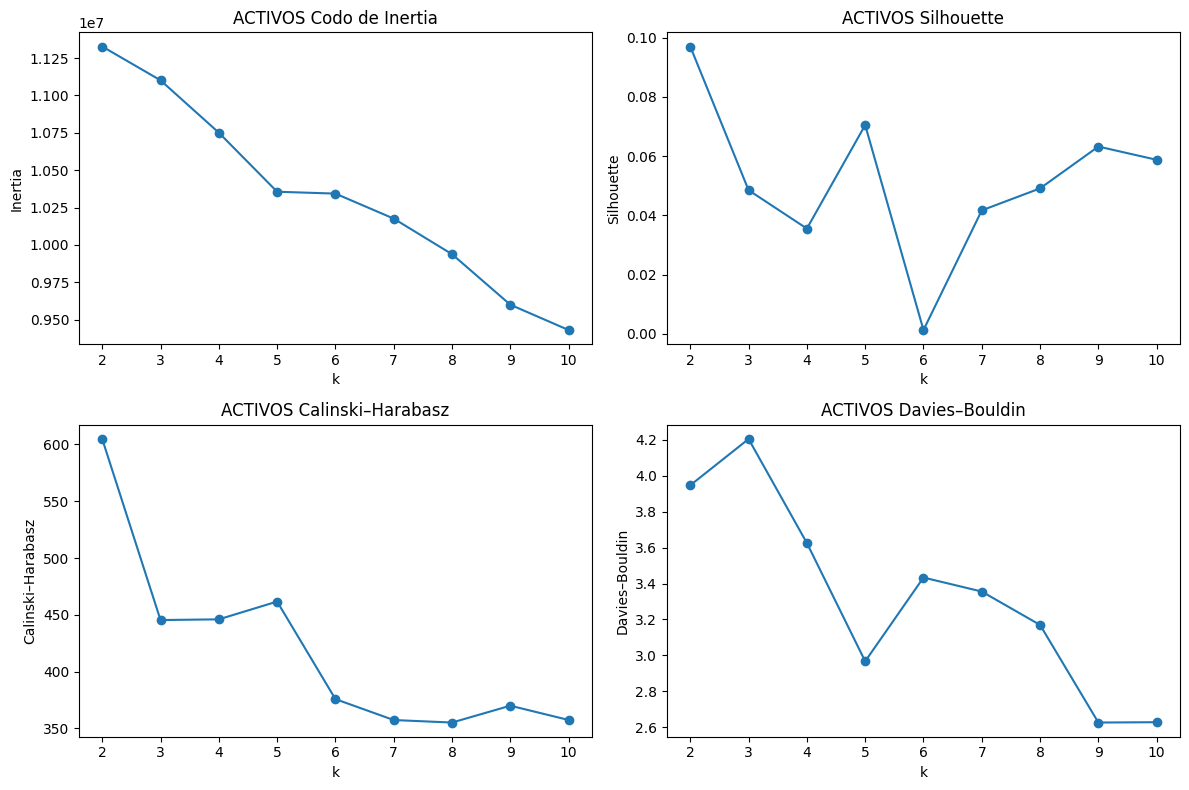


==== Métricas de calidad K-means [ACTIVOS] ====
k= 2 | inertia=11327024.98 | silhouette=0.0970 | calinski=604.76 | davies=3.9477
k= 3 | inertia=11101109.98 | silhouette=0.0485 | calinski=445.43 | davies=4.2053
k= 4 | inertia=10750972.79 | silhouette=0.0355 | calinski=446.05 | davies=3.6259
k= 5 | inertia=10356067.76 | silhouette=0.0705 | calinski=461.71 | davies=2.9671
k= 6 | inertia=10343557.50 | silhouette=0.0013 | calinski=375.84 | davies=3.4337
k= 7 | inertia=10176332.87 | silhouette=0.0417 | calinski=357.44 | davies=3.3556
k= 8 | inertia=9938444.44 | silhouette=0.0491 | calinski=355.23 | davies=3.1696
k= 9 | inertia=9600642.72 | silhouette=0.0632 | calinski=370.05 | davies=2.6259
k=10 | inertia=9431287.66 | silhouette=0.0588 | calinski=357.47 | davies=2.6279

Mejor k por silhouette: 2
Mejor k por Davies–Bouldin: 9
Sugerencias: {'best_by_silhouette': 2, 'best_by_davies_bouldin': 9, 'best_by_score_compuesto': 2}
Selección final según criterio: 2

Tamaño por cluster [ACTIVOS]:
Clust

In [7]:
# BLOQUE: Segmentación ACTIVOS

df_base = df_filtrado
RANDOM_STATE = 42
KS_ACT = list(range(2, 11))
SAMPLE_METRICS_ACT = 12000

# Prepara características con valor seguro para SVD
X_act, Z_tmp, df_act, info_act = build_features_for_segment(
    df_base,
    segmento="ACTIVOS",
    n_components_svd=2,
    drop_cancel_cols=True,
    random_state=RANDOM_STATE
)

# Ajuste dinámico real
from sklearn.decomposition import TruncatedSVD
n_components_svd_act = min(100, X_act.shape[1])
svd = TruncatedSVD(n_components=n_components_svd_act, random_state=RANDOM_STATE)
Z_act = svd.fit_transform(X_act)


# Barrido de k y métricas con criterio compuesto
metrics_act, models_act, labels_act_by_k, suggest_act, best_k_act = sweep_k_and_plot(
    X_act, Z_act, KS_ACT, method="mini-batch",
    random_state=RANDOM_STATE,
    sample_for_metrics=SAMPLE_METRICS_ACT,
    title_prefix="ACTIVOS",
    criterio="score_compuesto"
)

print_metrics_summary(metrics_act, segmento="ACTIVOS", suggestion=suggest_act, k_best=best_k_act)

# Etiquetas y tamaños por cluster
labels_act = labels_act_by_k[best_k_act]
print_cluster_sizes(labels_act, segmento="ACTIVOS")


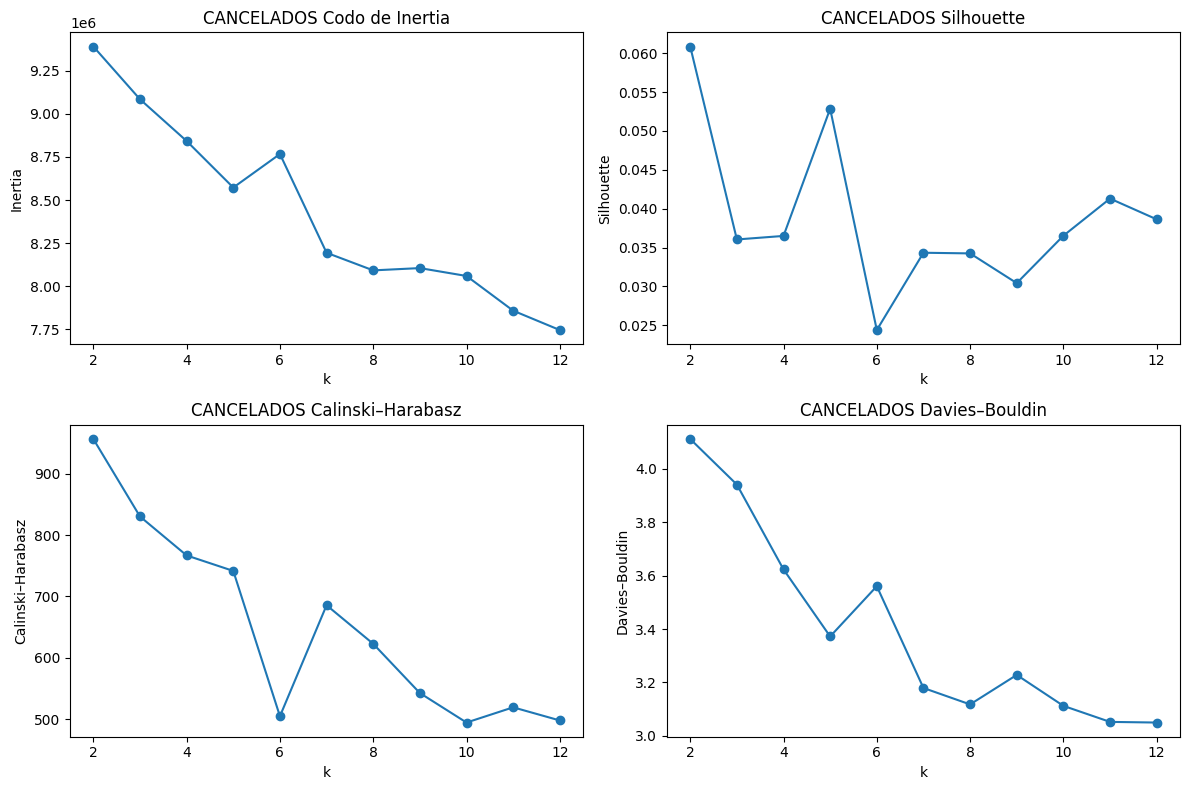


==== Métricas de calidad K-means [CANCELADOS] ====
k= 2 | inertia=9392156.03 | silhouette=0.0608 | calinski=956.85 | davies=4.1122
k= 3 | inertia=9085541.06 | silhouette=0.0360 | calinski=830.42 | davies=3.9414
k= 4 | inertia=8842887.09 | silhouette=0.0365 | calinski=766.89 | davies=3.6236
k= 5 | inertia=8572385.13 | silhouette=0.0528 | calinski=741.62 | davies=3.3723
k= 6 | inertia=8767240.54 | silhouette=0.0244 | calinski=504.57 | davies=3.5606
k= 7 | inertia=8193351.41 | silhouette=0.0343 | calinski=685.66 | davies=3.1792
k= 8 | inertia=8091030.45 | silhouette=0.0343 | calinski=622.69 | davies=3.1177
k= 9 | inertia=8104301.07 | silhouette=0.0304 | calinski=542.38 | davies=3.2281
k=10 | inertia=8058517.58 | silhouette=0.0365 | calinski=494.25 | davies=3.1122
k=11 | inertia=7856797.99 | silhouette=0.0413 | calinski=519.07 | davies=3.0521
k=12 | inertia=7744230.62 | silhouette=0.0386 | calinski=497.65 | davies=3.0497

Mejor k por silhouette: 2
Mejor k por Davies–Bouldin: 12
Sugerencia

In [8]:

# BLOQUE: Segmentación CANCELADOS

# Parámetros específicos para CANCELADOS
RANDOM_STATE = 42
KS_CAN = list(range(2, 13))     # k desde 2 a 12, mayor granularidad
SAMPLE_METRICS_CAN = 20000

# Prepara caract con un valor seguro para SVD
X_can, _, df_can, info_can = build_features_for_segment(
    df_base,
    segmento="CANCELADOS",
    n_components_svd=2,          # mínimo válido para evitar error
    drop_cancel_cols=False,
    random_state=RANDOM_STATE
)

# Ajuste dinámico real del n comp
from sklearn.decomposition import TruncatedSVD

n_components_svd_can = min(100, X_can.shape[1])
svd_can = TruncatedSVD(n_components=n_components_svd_can, random_state=RANDOM_STATE)
Z_can = svd_can.fit_transform(X_can)

# Barrido de k
metrics_can, models_can, labels_can_by_k, suggest_can, best_k_can = sweep_k_and_plot(
    X_can, Z_can, KS_CAN, method="mini-batch",
    random_state=RANDOM_STATE,
    sample_for_metrics=SAMPLE_METRICS_CAN,
    title_prefix="CANCELADOS"
)

# Imprime metricas y sugerencias
print_metrics_summary(metrics_can, segmento="CANCELADOS", suggestion=suggest_can, k_best=best_k_can)
print(f"Selección final de k para CANCELADOS: {best_k_can}")

# Etiquetas y tamaños por cluster
labels_can = labels_can_by_k[best_k_can]
print_cluster_sizes(labels_can, segmento="CANCELADOS")



Vemos ACTIVOS quedándose en 2 clusters y CANCELADOS en 5 es un comportamiento típico de:

*   ACTIVOS: datos más homogéneos, baja dispersión, K-means tendera a agrupar pocos clusteres grandes
*   CANCELADOS: mayor heterogeneidad (motivos de cancelación, antigüedad, uso), por eso el criterio compuesto detecta más granularidad.

***Si UMAP+HDBSCAN encontro más clusters en ACTIVOS, significa que hay microestructuras que K-means no detecto.***

Si ambos métodos coinciden en CANCELADOS (4-6 clusters), eso refuerza la segmentación que ya se hizo en umap.

GRAFICOS PARA KMEANS

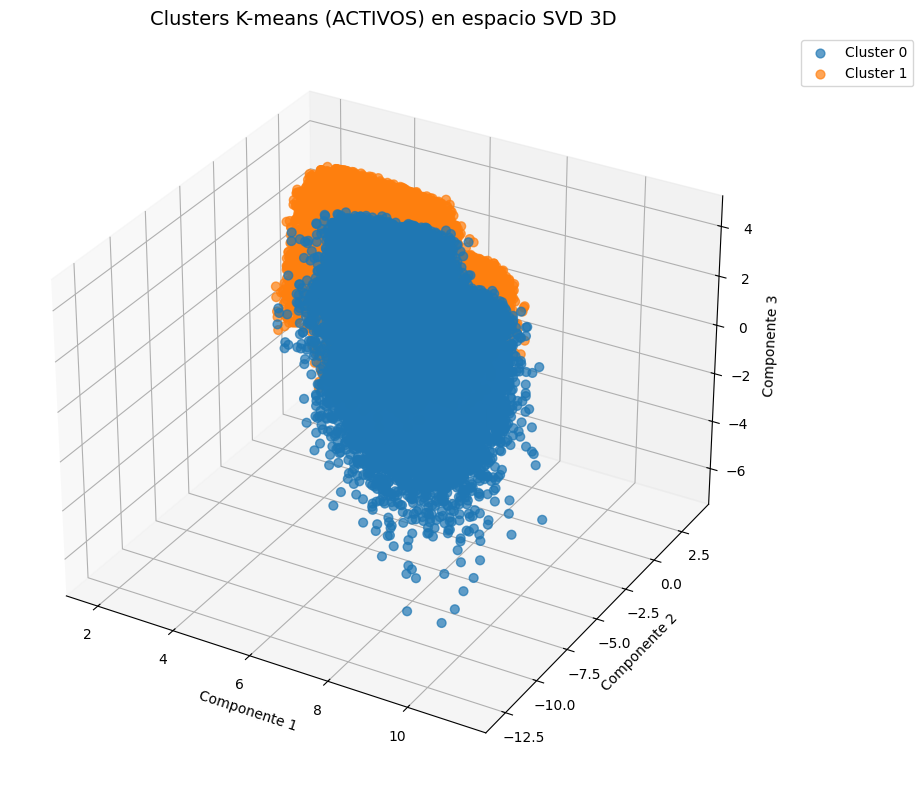

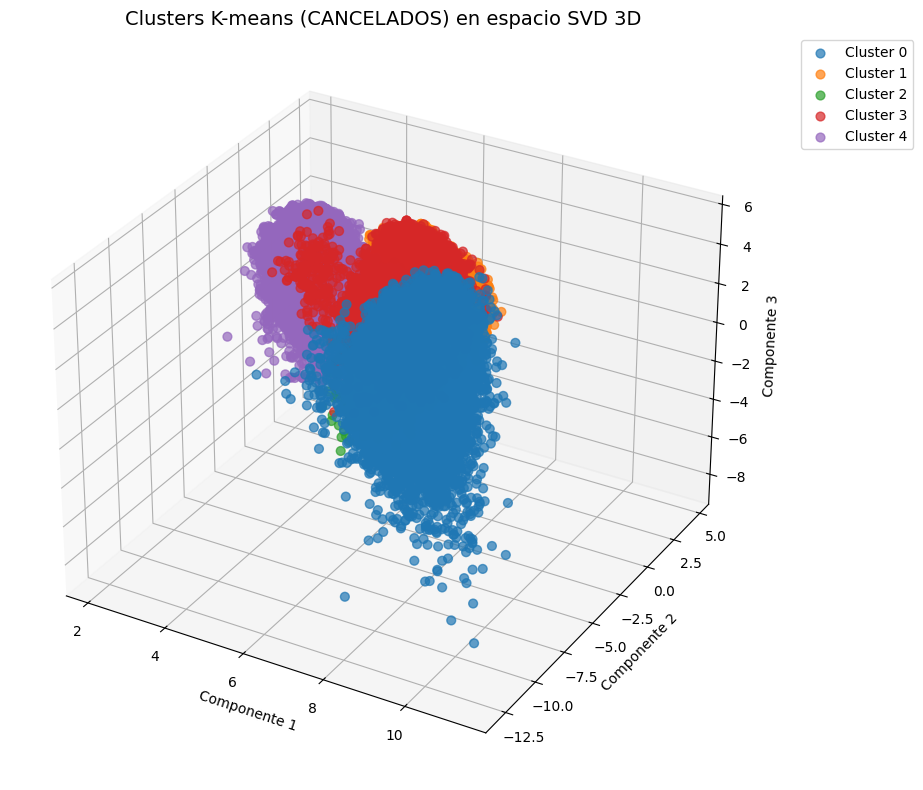

In [10]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

def plot_clusters_3d(Z, labels, segmento):
    """
    Visualiza usando las tres primeras componentes de Z SVD
    """
    if Z.shape[1] < 3:
        raise ValueError("Z debe tener al menos 3 componentes para graficar.")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Paleta de colores
    palette = sns.color_palette("tab10", len(set(labels)))

    for cluster_id in set(labels):
        idx = labels == cluster_id
        ax.scatter(
            Z[idx, 0], Z[idx, 1], Z[idx, 2],
            s=40, alpha=0.7,
            color=palette[cluster_id],
            label=f"Cluster {cluster_id}"
        )

    ax.set_title(f"Clusters K-means ({segmento}) en espacio SVD", fontsize=14)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.set_zlabel("Componente 3")
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()

# Visualización para ACTIVOS
plot_clusters_3d(Z_act, labels_act, segmento="ACTIVOS")

# Visualización para CANCELADOS
plot_clusters_3d(Z_can, labels_can, segmento="CANCELADOS")



AQUI INTENTO EL K MEANS MANUALMENTE CON K=5(numero aleatorio mas alto para ver que hace en comparacion con el score automatico que lo setea en 2)


=== Resultados K-means ACTIVOS con k=5 ===
Inertia: 10356067.76
Silhouette: 0.0731
Calinski-Harabasz: 205.48
Davies-Bouldin: 2.9491

Tamaño por cluster:
Cluster 0: n=17386
Cluster 1: n=6026
Cluster 2: n=41021
Cluster 3: n=76314
Cluster 4: n=67514


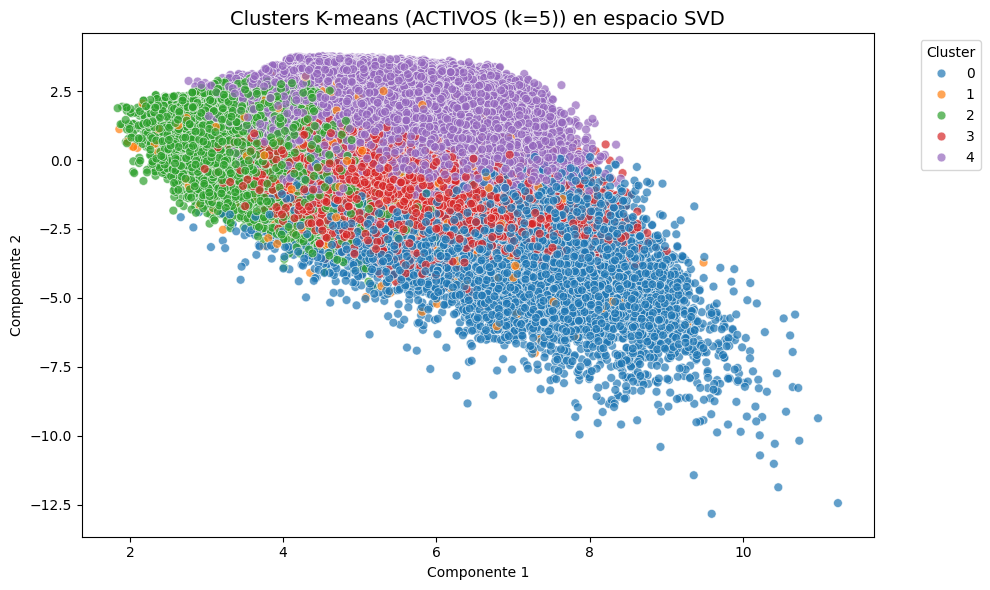

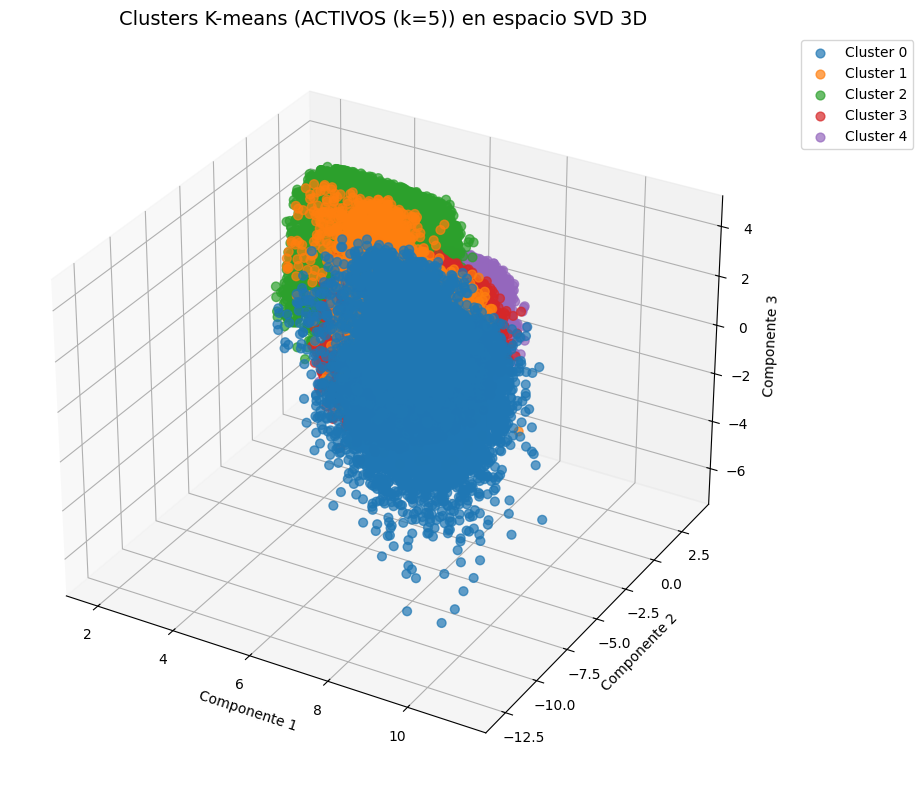

In [12]:

# K-means con k=5 para ACTIVOS
k_forzado = 5
km_act_5, labels_act_5, metrics_act_5 = fit_kmeans_and_metrics(
    X_act, Z_act, k=k_forzado, method="mini-batch", random_state=RANDOM_STATE
)

# Metricas
print(f"\n= Resultados K-means ACTIVOS con k={k_forzado} =")
print(f"Inertia: {metrics_act_5['inertia']:.2f}")
print(f"Silhouette: {metrics_act_5['silhouette']:.4f}")
print(f"Calinski-Harabasz: {metrics_act_5['calinski_harabasz']:.2f}")
print(f"Davies-Bouldin: {metrics_act_5['davies_bouldin']:.4f}")

# Tamaños por cluster
print("\nTamaño por cluster:")
vals, counts = np.unique(labels_act_5, return_counts=True)
for k, n in zip(vals, counts):
    print(f"Cluster {k}: n={n}")

# 2D
plot_clusters(Z_act, labels_act_5, segmento=f"ACTIVOS (k={k_forzado})")

# 3D
plot_clusters_3d(Z_act, labels_act_5, segmento=f"ACTIVOS (k={k_forzado})")


# GENERA PERFILADO DE CLUSTERES

In [17]:

def generar_storytelling_completo(df, cluster_col, top_n_cat=3):
    """
    Genera un storytelling enriquecido por cluster:
    - Promedios numéricos (vigencia, uso de servicios, interacciones).
    - Top categorías en variables demográficas y operativas.
    """
    perfiles = {}

    num_vars = [
        "meses_transcurridos", "Prestaciones_PAC", "Prestaciones_PBS",
        "Felicitaciones_PAC", "Felicitaciones_PBS",
        "Inquietud_PAC", "Inquietud_PBS",
        "Peticion_PAC", "Peticion_PBS",
        "Queja_PAC", "Queja_PBS",
        "Sugerencia_PAC", "Sugerencia_PBS"
    ]
    cat_vars = [
        "PLAN", "NIVEL_INGRESO", "CONDICION_SALUD",
        "SEGMENTO_EDAD_01_DEPENDIENTE", "SEGMENTO_EDAD_02_ADULTOJOVEN",
        "SEGMENTO_EDAD_03_PRODUCTIVO", "SEGMENTO_EDAD_04_ADULTOMAYOR",
        "TIPO_AFILIADO_ASEGURADO COLECTIVO", "TIPO_AFILIADO_ASEGURADO FAMILIAR",
        "Regional_Agrupadora_CENTRO", "Regional_Agrupadora_NORTE",
        "Regional_Agrupadora_SUR"
    ]

    for cluster_id, grupo in df.groupby(cluster_col):
        perfil = {}
        perfil["promedios"] = grupo[num_vars].mean().round(2).to_dict()

        # Top categorías
        top_categorias = {}
        for var in cat_vars:
            if var in grupo.columns:
                top_vals = grupo[var].value_counts(normalize=True).head(top_n_cat)
                top_categorias[var] = [(cat, round(freq*100, 1)) for cat, freq in top_vals.items()]

        # Construcción del storytelling
        texto = f"Cluster {cluster_id}: "
        texto += f"Vigencia promedio: {perfil['promedios'].get('meses_transcurridos', 0)} meses. "
        texto += f"Uso PBS: {perfil['promedios'].get('Prestaciones_PBS', 0)}, PAC: {perfil['promedios'].get('Prestaciones_PAC', 0)}. "
        texto += f"Interacciones: Quejas {perfil['promedios'].get('Queja_PAC', 0)} PAC / {perfil['promedios'].get('Queja_PBS', 0)} PBS; "
        texto += f"Felicitaciones {perfil['promedios'].get('Felicitaciones_PAC', 0)} PAC / {perfil['promedios'].get('Felicitaciones_PBS', 0)} PBS. "
        texto += "Categorías dominantes: "
        for var, vals in top_categorias.items():
            texto += f"{var} -> " + ", ".join([f"{cat} ({freq}%)" for cat, freq in vals]) + "; "

        perfiles[cluster_id] = texto

    return perfiles

# CANCELADOS

df_can["cluster"] = labels_can
storytelling_can = generar_storytelling_completo(df_can, "cluster")
print("\n=== Caracteristicas CANCELADOS ===")
for cluster_id, descripcion in storytelling_can.items():
    print(descripcion)

# ACTIVOS

df_act["cluster"] = labels_act
storytelling_act = generar_storytelling_completo(df_act, "cluster")
print("\n=== Caracteristicas ACTIVOS ===")
for cluster_id, descripcion in storytelling_act.items():
    print(descripcion)

# ACTIVOS con k=5 (forzado)

df_act["cluster_k5"] = labels_act_5
storytelling_act_k5 = generar_storytelling_completo(df_act, "cluster_k5")
print("\n=== Caracteristicas ACTIVOS k=5 ===")
for cluster_id, descripcion in storytelling_act_k5.items():
    print(descripcion)



=== Caracteristicas CANCELADOS ===
Cluster 0: Vigencia promedio: 34.53 meses. Uso PBS: 214.66, PAC: 8.74. Interacciones: Quejas 0.69 PAC / 0.22 PBS; Felicitaciones 0.0 PAC / 0.01 PBS. Categorías dominantes: PLAN -> 3 (60.5%), 1 (16.9%), 2 (13.6%); NIVEL_INGRESO -> 1 (57.2%), 2 (30.3%), 3 (12.5%); CONDICION_SALUD -> 2 (64.0%), 1 (29.5%), 3 (6.5%); SEGMENTO_EDAD_01_DEPENDIENTE -> 0 (94.2%), 1 (5.8%); SEGMENTO_EDAD_02_ADULTOJOVEN -> 0 (66.2%), 1 (33.8%); SEGMENTO_EDAD_03_PRODUCTIVO -> 0 (54.8%), 1 (45.2%); SEGMENTO_EDAD_04_ADULTOMAYOR -> 0 (84.7%), 1 (15.3%); TIPO_AFILIADO_ASEGURADO COLECTIVO -> 0 (99.2%), 1 (0.8%); TIPO_AFILIADO_ASEGURADO FAMILIAR -> 0 (76.2%), 1 (23.8%); Regional_Agrupadora_CENTRO -> 1 (52.5%), 0 (47.5%); Regional_Agrupadora_NORTE -> 0 (85.2%), 1 (14.8%); Regional_Agrupadora_SUR -> 0 (93.6%), 1 (6.4%); 
Cluster 1: Vigencia promedio: 16.25 meses. Uso PBS: 11.7, PAC: 2.29. Interacciones: Quejas 0.05 PAC / 0.01 PBS; Felicitaciones 0.0 PAC / 0.0 PBS. Categorías dominantes:

# ANALISIS CANCELADOS K-MEANS

Cluster 0

Vigencia alta: 34,5 meses, clientes antiguos.
Uso PBS muy alto: 214,6 - usuarios crónicos o con alta carga asistencial.
PAC moderado: 8,7.
Quejas: 0,69 PAC / 0,22 PBS, interacción negativa significativa.
Perfil dominante: PLAN 3 (60%), ingreso bajo (57%), salud 2 (64%).
Edad: mayormente adultos jóvenes y productivos.
Región: Centro (52%).

Cluster 1

Vigencia media-baja: 16,2 meses.
Uso PBS mínimo: 11,7, baja interacción con servicios.
PAC bajo: 2,3.
Quejas casi nulas.
Perfil dominante: PLAN 3 (50%), ingreso bajo (66%), salud 1 (71%).
Edad: dependientes predominan (72%).
Afiliación: familiar casi total (99%).

Cluster 2

Vigencia baja: 11,7 meses, cancelación temprana.
Uso PBS mínimo: 9,0.
PAC muy bajo: 1,2.
Quejas nulas.
Perfil dominante: PLAN 3 (56%), ingreso bajo (60%), salud 1 (59%).
Edad: mezcla entre adulto joven y productivo.

Cluster 3

Vigencia media: 25,1 meses.
Uso PBS moderado: 20,2.
PAC medio: 4,7.
Quejas bajas.
Perfil dominante: PLAN 3 (83%), ingreso más distribuido, salud 1 (62%).
Edad: más adultos jóvenes y productivos.

Cluster 4

Vigencia media: 20,1 meses.
Uso PBS moderado: 25,2.
PAC bajo: 2,3.
Quejas bajas.
Perfil dominante: PLAN 3 (59%), ingreso bajo (46%), salud 1 (61%).
Edad: mezcla entre dependientes y adultos jóvenes.

**resumen:**

**Cluster 0** es el más crítico: alta vigencia + uso intensivo de PBS + muchas quejas → clientes costosos y exigentes.

**Clusters 1 y 2** son cancelaciones tempranas con baja interacción → oportunidad para programas de onboarding y fidelización.

**Clusters 3 y 4** son intermedios, con uso moderado y perfiles más variados → potencial para estrategias segmentadas.

# ANALISIS PARA ACTIVOS (K=2 por SCORE)

Cluster 0

Vigencia muy alta: 52 meses, clientes antiguos y estables.
Uso PBS extremadamente alto: 442, usuarios crónicos o con alta carga asistencial.
PAC bajo: 1,07 - poca interacción en servicios complementarios.
Quejas elevadas: 1,04 PAC / 0,25 PBS, clientes exigentes, potencialmente insatisfechos.
Perfil dominante: PLAN 3 (72%), ingreso bajo (49%), salud 2 (82%), población con condiciones crónicas.
Edad: mayoría productivos y adultos mayores (22%).
Región: Centro (58%).

Cluster 1

Vigencia media-alta: 39 meses.
Uso PBS muy bajo: 37, clientes sanos o con baja interacción.
PAC mínimo: 0,6.
Quejas casi nulas: 0,15 PAC / 0,03 PBS.
Perfil dominante: PLAN 3 (66%), ingreso bajo (43%), salud 1 (66%), población sana.
Edad: más dependientes (36%) y adultos jóvenes (28%).
Afiliación: familiar relevante (47%).

**Resumen**

**Cluster 0**: Clientes de alto costo y alta interacción negativa, requieren gestión activa y programas de control de gasto.

**Cluster 1**: Clientes sanos, baja interacción, oportunidad para fidelización y venta cruzada.

# ANALISIS K MEANS ACTIVO CON K=5 FORZADO

Cluster 0

Vigencia altísima: 56,7 meses, clientes muy antiguos.
Uso PBS extremo: 1132, súper usuarios crónicos, alto costo.
PAC bajo: 0,96.
Quejas elevadas: 2,13 PAC / 0,54 PBS, clientes exigentes y conflictivos.
Perfil dominante: PLAN 3 (64%), ingreso bajo (55%), salud 2 (61%), población con condiciones crónicas y alta demanda.
Edad: fuerte presencia de adultos mayores (51%).
Región: Centro (54%).

Cluster 1

Vigencia alta: 48 meses.
Uso PBS moderado: 186, clientes con necesidades frecuentes pero no extremos.
Quejas bajas: 0,49 PAC / 0,12 PBS.
Perfil dominante: PLAN 3 (70%), ingreso bajo (43%), salud 2 (55%).
Edad: mezcla entre dependientes y productivos.

Cluster 2

Vigencia media: 39,9 meses.
Uso PBS bajo: 90, clientes sanos o con baja interacción.
Quejas mínimas: 0,26 PAC / 0,06 PBS.
Perfil dominante: PLAN 3 (70%), ingreso medio (40%), salud 1 (50%).
Edad: más adultos jóvenes y productivos.

Cluster 3

Vigencia media-alta: 43,4 meses.
Uso PBS bajo-moderado: 104.
Quejas moderadas: 0,38 PAC / 0,09 PBS.
Perfil dominante: PLAN 3 (73%), ingreso bajo (44%), salud 2 (56%).
Edad: productivos predominan.

Cluster 4

Vigencia media-alta: 42,3 meses.
Uso PBS mínimo: 66, clientes sanos, baja interacción.
Quejas mínimas: 0,23 PAC / 0,05 PBS.
Perfil dominante: PLAN 3 (62%), ingreso bajo (54%), salud 1 (59%).
Edad: más dependientes (60%).

**Resumen**

**Cluster 0:** Altísimo costo y conflictividad, gestión prioritaria, programas de control de gasto y atención personalizada.

**Cluster 1**: Clientes frecuentes pero menos conflictivos, fidelización y programas preventivos.

**Clusters 2, 3 y 4**: Clientes sanos o con baja interacción, oportunidad para venta cruzada y retención.